In [1]:
import sklearn as sk 
from sklearn import preprocessing as p
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from skimage.transform import resize
import cv2
import math
import statistics as stat
from PIL import Image
import os
import csv
from sklearn.metrics import accuracy_score

## Dataset

Source : [CASIA HWDB — Handwritten Chinese Characters (Kaggle)](https://www.kaggle.com/datasets/pascalbliem/handwritten-chinese-character-hanzi-datasets)

## Liste des chemins / Noms des caractères

In [64]:
listedespaths=[]
path = 'CASIA-HWDB_Train' # Chemin vers le répertoire de données
files = os.listdir(path) # Récupère les fichiers du répertoire
for name in files:
    listedespaths.append(name)
    print(name)
# Encode les noms de dossiers en entiers (évite les conflits d'encodage)
le=p.LabelEncoder() 
le.fit(listedespaths)
classes=le.transform(listedespaths)
# Les noms de fichiers utilisent un encodage non-standard : on les convertit en entiers via LabelEncoder
print(classes)
print(len(classes))

ň«¬
ň«á
ň«â
ň«ä
ň«Ç
ň«ë
ň«í
ň«î
ň«ô
ň«Ö
ň«×
ň«Ą
ň«Ć
ň«Č
ň«Ľ
ň«ł
ň«│
ň«┐
ň«┤
ň«╣
ň«░
[ 0  4  5  6  1  7  8  9 10  2  3 11 12 13 14 15 16 17 18 19 20]
21
<class 'numpy.ndarray'>


In [65]:
# Utilitaire : ouvre une image et la convertit en tableau NumPy en niveaux de gris
def imageOpener(s):
    im = Image.open(s)
    im=im.convert('L')
    im=np.array(im)
    return im

In [66]:
# Retourne les dimensions (hauteur, largeur) d'une image
def tupleLargeurhauteur(s):
    im = Image.open(s)
    im=im.convert('L')
    im=np.array(im)
    return im.shape
print(tupleLargeurhauteur('CASIA-HWDB_Train\ň«¬\\1.png'))

(61, 62)


In [67]:
def largeurhauteurdesimagesparcaractere(filename):
    hauteur=[]
    largeur=[]
    for i in range(1,600):
        try :
            s='CASIA-HWDB_Train\\'+filename+'\\'+str(i)+'.png'
            tupleLargeurhauteur(s)
            hauteur.append(tupleLargeurhauteur(s)[0])
            largeur.append(tupleLargeurhauteur(s)[1])
        except :
            continue
    moylong=stat.mean(hauteur)
    moylarg=stat.mean(largeur)
    ectplong=np.std(hauteur)
    ectplarg=np.std(largeur)
    maxlong=max(hauteur)
    maxlarg=max(largeur)
    return (ectplong,ectplarg,maxlong,maxlarg)

# Calcule l'écart-type et le maximum des dimensions pour tous les samples d'un caractère
# Un grand écart-type implique des tailles très variables => le simple contourage blanc serait insuffisant

In [68]:
listedesdetails=[]
for i in listedespaths:
    listedesdetails.append(largeurhauteurdesimagesparcaractere(i))
    print
def MoyenneEtMax(listeAvecTuplede4):
    listeectplong=[]
    listeectplarg=[]
    listemaxlong=[]
    listemaxlarg=[]
    for k in range(len(listeAvecTuplede4)) :
        listeectplong.append(listeAvecTuplede4[k][0])
        listeectplarg.append(listeAvecTuplede4[k][1])
        listemaxlong.append(listeAvecTuplede4[k][2])
        listemaxlarg.append(listeAvecTuplede4[k][3])
    moyectplong=stat.mean(listeectplong)
    moyectplarg=stat.mean(listeectplarg)
    maxlong=max(listemaxlong)
    maxlarg=max(listemaxlarg)
    return moyectplong,moyectplarg,maxlong,maxlarg

print(MoyenneEtMax(listedesdetails))
## L'écart-type est suffisamment faible : le contourage blanc est applicable
# Les deux dernières valeurs sont les dimensions maximales (hauteur, largeur) observées dans le dataset

f
(13.916786439389774, 11.353012779499524, 210, 179)


In [69]:
matricebase=np.ones((210,179))
matricebase=matricebase*255
print(matricebase)
# Crée une matrice blanche de la taille maximale observée (210x179)

[[255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 ...
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]]


In [70]:
def countourageBlanc(matricecharac, matriceref) :
    disthauteur=math.ceil((len(matriceref)-len(matricecharac))/2) # math.ceil pour éviter les demi-pixels
    distlargeur=math.ceil((len(matriceref[0])-len(matricecharac[0]))/2)
    matriceref[disthauteur:disthauteur+len(matricecharac), distlargeur:distlargeur+len(matricecharac[0])] = matricecharac
    return matriceref
            
# Centre l'image dans la matrice blanche (padding symétrique)

## Visualisation d'une image

94
68
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


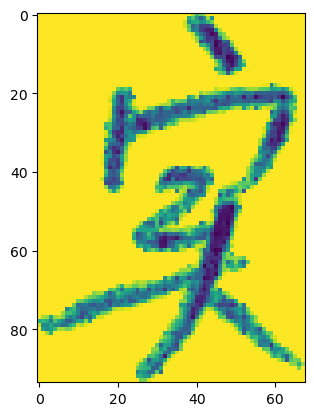

In [71]:
# Test : affichage d'une image brute
img = np.asarray(Image.open('CASIA-HWDB_Train\Test\ň«×\9.png'))
print(len(img))
print(len(img[0]))
print(img)
imgplot = plt.imshow(img)

## Normalisation (contourage blanc)

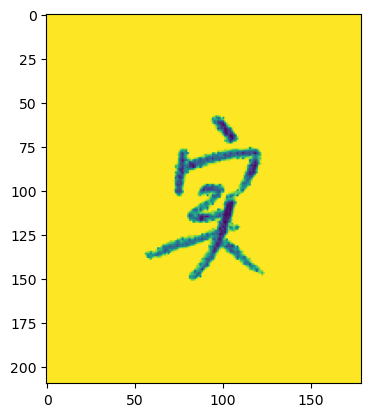

In [72]:
# Test : affichage après normalisation (contourage blanc)
imgtest = countourageBlanc(img, matricebase)
imgplot = plt.imshow(imgtest)

## Création du CSV — matrices aplaties des images

> **Attention :** cette étape est très lourde en mémoire et en temps de calcul.

In [ ]:
# Aplatit une image normalisée en vecteur 1D
def creerImage1D(imagepath,matricebase):
    img = imageOpener(imagepath)
    matricecontouree=countourageBlanc(img, matricebase)
    matrice1D=matricecontouree.flatten().tolist()
    return matrice1D

# Crée les noms de colonnes : "class" + "index0" à "indexN"

def creerindexpixels():
    return ['class']+['index' + str(i) for i in range(0, 210*179)]

index=creerindexpixels()

print('nombre de cols : ', len(index))

# Construit la liste complète de toutes les matrices 1D pour un dossier de caractère

def creerlistedesmatrices1Dpourunfichier(listedesmatrices,nomfichier,index,matricebase,classe):
  
    for i in range(1,600): #600 nombre d'images max pour un caractère
        try :
            imagepath='CASIA-HWDB_Train\\'+nomfichier+'\\'+str(i)+'.png'
            matrice1D=creerImage1D(imagepath,matricebase)
            if(matrice1D):
                matrice1D.insert(0, classe)
                listedesmatrices.append(matrice1D)
        except :
            continue
    return listedesmatrices

# Paramètres globaux
matricebase=np.ones((210,179))
matricebase=matricebase*255
index=creerindexpixels()
classes = classes.tolist()
##############################################################################
# ⚠️ ATTENTION : la génération est rapide pour 1-3 classes mais ralentit fortement au-delà
##############################################################################

classes = classes[0:2]  # Fichier CSV pour 2 classes
# classes = classes[0:3]  # Fichier CSV pour 3 classes
# classes = classes[0:4]  # Fichier CSV pour 4 classes
# classes = classes[0:7]  # Fichier CSV pour 7 classes
print('nombre de classes :' + len(classes))
# Initialisation de la liste et itération sur toutes les classes

listedesmatrices=[]
listedesmatrices.append(index)

# Itération sur chaque classe pour remplir la liste

for j in range(len(classes)) :
    path=listedespaths[j]
    classe=classes[j]
    listedesmatrices=creerlistedesmatrices1Dpourunfichier(listedesmatrices,path,index,matricebase,classe)
    
print('nombre de photos :' + len(listedesmatrices))
      
# Écriture dans le fichier CSV
# Renommer le fichier CSV selon le nombre de classes souhaité
with open('pixelstrainXclasse.csv', mode='w', newline='') as fichier_csv:
    writer = csv.writer(fichier_csv, delimiter=',')    # Écriture des en-têtes
    writer.writerow(listedesmatrices[0])    # Écriture des valeurs de pixel
    for pixels in listedesmatrices[1:]:
        writer.writerow(pixels)
     

37591
[0, 4, 5, 6, 1, 7, 8]
3831


In [ ]:
# Note : le chargement du CSV en mémoire est lent (fichier volumineux)

# Lecture du fichier CSV
data = pd.read_csv('pixelstrain7classe.csv')
print('fini')

In [ ]:
# Début de la partie Machine Learning : séparation train/test

from sklearn.model_selection import train_test_split

x = data.drop(columns='class')
y = data['class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101)

In [ ]:
# Réduction de dimensionnalité par PCA

from sklearn.decomposition import PCA

n_components = 50  # Taille du vecteur réduit — compromis entre performance et surapprentissage
pca = PCA(n_components=n_components)

# Application de la PCA sur les données d'entraînement
x_train_pca = pca.fit_transform(x_train)

# print(x_train_pca[0])  # Décommenter pour inspecter le premier vecteur réduit


In [ ]:
# Reconstruction de l'image originale depuis l'espace réduit PCA (vérification visuelle de la perte d'information)
x_train_reconstructed = np.dot(x_train_pca, pca.components_) + pca.mean_
img=x_train_reconstructed[0].reshape(210, 179)
imgplot = plt.imshow(img)

In [ ]:
x_test_pca = pca.fit_transform(x_test)

## Support Vector Classifier (SVC)

In [ ]:
# SVC avec noyau linéaire

from sklearn.svm import SVC

# Créer un modèle SVC
modelSVClin = SVC(kernel="linear")

# Entraîner le modèle sur les données PCA transformées
modelSVClin.fit(x_train_pca, y_train)

y_pred = modelSVClin.predict(x_test_pca)
# Calculer la précision du modèle
accuracySVC1 = accuracy_score(y_test, y_pred)
print("Précision du modèle : {:.2f}%".format(accuracySVC1 * 100))

In [ ]:
# SVC avec noyau polynomial (degré 4)

# Créer un modèle SVC
modelSVCpoly = SVC(kernel="poly", degree=4)

# Entraîner le modèle sur les données PCA transformées
modelSVCpoly.fit(x_train_pca, y_train)

y_pred = modelSVCpoly.predict(x_test_pca)

# Calculer la précision du modèle
accuracySVC2 = accuracy_score(y_test, y_pred)
print("Précision du modèle : {:.2f}%".format(accuracySVC2 * 100))

In [ ]:
# SVC avec noyau RBF (Radial Basis Function)

# Créer un modèle SVC
modelSVCrbf = SVC(kernel="rbf", gamma='scale')

# Entraîner le modèle sur les données PCA transformées
modelSVCrbf.fit(x_train_pca, y_train)

y_pred = modelSVCrbf.predict(x_test_pca)

# Calculer la précision du modèle
accuracySVC3 = accuracy_score(y_test, y_pred)
print("Précision du modèle : {:.2f}%".format(accuracySVC3 * 100))

In [ ]:
# SVC avec noyau sigmoïde

# Créer un modèle SVC
modelSVCSig = SVC(kernel="sigmoid")

# Entraîner le modèle sur les données PCA 
modelSVCSig.fit(x_train_pca, y_train)

y_pred = modelSVCSig.predict(x_test_pca)

# Calculer la précision du modèle
accuracySVC4 = accuracy_score(y_test, y_pred)
print("Précision du modèle : {:.2f}%".format(accuracySVC4 * 100))

In [ ]:
# Représentation graphique des performances SVC selon le type de noyau

# Définir les hyperparamètres à tester
hyperparam_values = ['linear', 'poly', 'rbf','sigmoid']

# Liste des scores de précision par noyau
performances = [accuracySVC1, accuracySVC2, accuracySVC3,accuracySVC4]

# Tracé du graphique
plt.plot(hyperparam_values, performances, marker='o')
plt.xlabel('Type de noyau')
plt.ylabel('% Prédit')
plt.title('Performances de l\'algorithme SVC en fonction des hyperparamètres')
plt.grid(True)
plt.show()


## K plus proches voisins (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(x_train_pca, y_train)

y_pred = knn.predict(x_test_pca)

# Calculer la précision du modèle
accuracyKneighboor = accuracy_score(y_test, y_pred)
print("Précision du modèle : {:.2f}%".format(accuracyKneighboor * 100))
 


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Définir les valeurs de k à tester
param_grid = {
    'n_neighbors': [2, 7, 9, 11, 21, 55, 67, 100, 150,300]
}

# Créer le modèle k-plus-proches voisins
model = KNeighborsClassifier()

# Créer l'objet GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)

# Effectuer la recherche d'hyperparamètres
grid_search.fit(x_train_pca, y_train)

# Afficher les meilleurs hyperparamètres trouvés
print("Meilleur nombre pour K+1 voisins : ", grid_search.best_params_)

# Obtenir les prédictions sur l'ensemble de test
y_pred = grid_search.predict(x_test_pca)

# Afficher le rapport de classification
print("Rapport de classification : ")
print(classification_report(y_test, y_pred))


In [ ]:
# Représentation graphique des performances selon les hyperparamètres

# Définir les hyperparamètres à tester
hyperparam_values = [2, 7, 9, 11, 21, 55, 67, 100, 150]

# Liste pour stocker les performances
performances = []

# Boucle sur les différentes valeurs des hyperparamètres
for hyperparam in hyperparam_values:
    # Initialiser et entraîner le modèle avec l'hyperparamètre donné
    modele = KNeighborsClassifier(n_neighbors=hyperparam)
    modele.fit(x_train_pca, y_train)
    
    # Évaluer les performances du modèle sur l'ensemble de test
    score = modele.score(x_test_pca, y_test)
    
    # Ajouter le score à la liste des performances
    performances.append(score)

# Tracer le graphique
plt.plot(hyperparam_values, performances, marker='o')
plt.xlabel('nombre de voisins')
plt.ylabel('% Prédit')
plt.title('Performances de l\'algorithme K+1 Neighboor en fonction des hyperparamètres')
plt.grid(True)
plt.show()


## Random Forest

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

modeleRandomForest = RandomForestClassifier(n_estimators=55)

# Entraînement du classificateur
modeleRandomForest.fit(x_train_pca, y_train)

# Prédiction sur l'ensemble de test
y_pred = modeleRandomForest.predict(x_test_pca)

# Calcul de l'exactitude (accuracy)
accuracyRF = accuracy_score(y_test, y_pred)
print("Exactitude : ", accuracyRF*100)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Recherche du meilleur hyperparamètre par GridSearchCV

# Définir les valeurs de k à tester
param_grid = {
    'n_estimators': [2, 7, 9, 11, 21, 55, 67, 100, 150]
}

# Créer le modèle k-plus-proches voisins
model = RandomForestClassifier()

# Créer l'objet GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)

# Effectuer la recherche d'hyperparamètres
grid_search.fit(x_train_pca, y_train)

# Afficher les meilleurs hyperparamètres trouvés
print("Meilleur nombre de forest : ", grid_search.best_params_)

# Obtenir les prédictions sur l'ensemble de test
y_pred = grid_search.predict(x_test_pca)

# Afficher le rapport de classification
print("Rapport de classification : ")
print(classification_report(y_test, y_pred))


In [ ]:
# Représentation graphique des performances selon les hyperparamètres

# Définir les hyperparamètres à tester
hyperparam_values = [2, 7, 9, 11, 21, 55, 67, 100, 150]

# Liste pour stocker les performances
performances = []

# Boucle sur les différentes valeurs des hyperparamètres
for hyperparam in hyperparam_values:
    # Initialiser et entraîner le modèle avec l'hyperparamètre donné
    modele = RandomForestClassifier(n_estimators=hyperparam)
    modele.fit(x_train_pca, y_train)
    
    # Évaluer les performances du modèle sur l'ensemble de test
    score = modele.score(x_test_pca, y_test)
    
    # Ajouter le score à la liste des performances
    performances.append(score)

# Tracer le graphique
plt.plot(hyperparam_values, performances, marker='o')
plt.xlabel('nombre d\'arbres')
plt.ylabel('% Prédit')
plt.title('Performances de l\'algorithme Random Forest en fonction des hyperparamètres')
plt.grid(True)
plt.show()